<a href="https://colab.research.google.com/github/ourharlequin/ai_workbooks/blob/main/Workshop_3_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Workshop: RAG with LangChain

**Lecture 3 — Retrieval-Augmented Generation**

In this workshop, you will:
1. Learn LangChain's core abstractions (LLM calls, prompts, chains)
2. Understand RAG building blocks (loaders, splitters, embeddings, vector stores)
3. Build a complete RAG pipeline from scratch
4. Test it — and see where it breaks

> We'll be searching for *the meaning of life* across a small philosophy corpus.

⏱️ **Time:** ~45 minutes

## Intro: The LangChain Ecosystem in 2026

LangChain started as a single library for chaining LLM calls.
Today it's a **family of packages**, each with a clear role.

**Core packages:**

- **langchain-core** — base abstractions: messages, prompts,
  output parsers, runnables (LCEL). Everything builds on this.
- **langchain** — high-level chains, agents, `create_*` helpers.
  What you use to build standard RAG and agent pipelines.
- **langchain-{provider}** — one package per integration
  (`langchain-openai`, `langchain-litellm`, `langchain-chroma`, ...).
  Install only what you need.
- **langchain-community** — community-maintained integrations
  not yet in their own package.
- **langchain-classic** — legacy chains and functionality.

**Beyond chains:**

- **LangGraph** — stateful graph-based orchestration. For agents that need branching, cycles, retries, or human-in-the-loop.
- **LangSmith / Langfuse** — observability: tracing, evaluation, monitoring. We'll cover it later.

**Key ideas:**

- **LCEL** (LangChain Expression Language) is the glue.
  Components connect with the pipe `|` operator:
  `prompt | llm | parser`. Each component is a "Runnable"
  with `.invoke()`, `.stream()`, and `.batch()`.

- **Provider packages are modular.** Switching from OpenAI
  to Gemini means changing only one import and one model string.

**Pros:**

- 700+ integrations — your LLM and database are probably supported.
- Fast prototyping — a working RAG pipeline in ~20 lines.
- Largest community — most tutorials and answers
  assume LangChain.
- Viable production via LangGraph + LangSmith.

**Cons:**

- Abstraction overhead — debugging means reading through
  several wrapper layers.
- API changes frequently — many 2024-2025 tutorials are already obsolete.
- Customization or usage of less popular tools can be a real pain.

*In this workshop we use: `langchain-core`, `langchain`,
`langchain-litellm`, `langchain-huggingface`,
and `langchain-chroma`.*

---
## Section 0 — Setup & Configuration

In [6]:
# 0.1  Install dependencies
# fmt: off
!pip install -q \
    langchain==1.2.14 \
    langchain-core \
    langchain-litellm \
    langchain-chroma \
    langchain-text-splitters \
    langchain-huggingface \
    sentence-transformers
# fmt: on

In [66]:
# 0.2  Choose your LLM provider
#
# LiteLLM lets you use the same interface for any provider.
# Uncomment ONE block below and paste your API key.

import os
from google.colab import userdata

#os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
#LLM_MODEL = "openai/gpt-5-nano"

#os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
#LLM_MODEL = "gemini/gemini-2.5-flash"

os.environ["MISTRAL_API_KEY"] = userdata.get("MISTRAL_API_KEY")
LLM_MODEL = "mistral/mistral-small-latest"

#os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
#LLM_MODEL = "openrouter/openai/gpt-5.4-nano"

In [36]:
# 0.3  Imports

import numpy as np
from langchain_litellm import ChatLiteLLM, LiteLLMEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import (
    RunnableLambda, RunnableParallel, RunnablePassthrough
)
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("All imports successful")

All imports successful


In [21]:
# 0.4  Initialize the LLM

llm = ChatLiteLLM(model=LLM_MODEL)

# Quick test
response = llm.invoke("Say bird in 3 languages.")
print(response.content)

Here are three ways to say **"bird"** in different languages:

1. **Spanish** – *pájaro* (general term) or *ave* (more formal)
2. **French** – *oiseau*
3. **German** – *Vogel*


---
## Section 1 — LangChain Basics

LangChain provides composable building blocks for LLM applications.
The three core concepts:

| Concept | What it does |
|---------|-------------|
| **Messages** | Structured input to chat models (system / human / AI) |
| **Prompt Templates** | Reusable prompts with variable slots |
| **Chains (LCEL)** | Connect components with the pipe `\|` operator |

### 1.1 — Messages & LLM calls

In [32]:
# Direct LLM call with messages

messages = [
    SystemMessage(content="You are a concise assistant."),
    HumanMessage(content="What is the meaning of life?"),
]

response = llm.invoke(messages)
print(response.content)

The meaning of life is a deeply philosophical question with no single, universally accepted answer. Different perspectives offer various interpretations:

1. **Philosophical**: Some argue it's about seeking happiness, knowledge, or self-fulfillment (e.g., Aristotle's *eudaimonia*).
2. **Religious/Spiritual**: Many traditions suggest it's tied to divine purpose, enlightenment, or moral living (e.g., Buddhism's *Nirvana*, Christianity's salvation).
3. **Scientific**: From an evolutionary standpoint, life's "purpose" may simply be survival and reproduction.
4. **Personal**: Many find meaning in relationships, creativity, or contributing to society.

Ultimately, the answer may depend on your beliefs, experiences, and values. What resonates with *you*?


### 1.2 — Prompt Templates

In [33]:
# Prompt templates let you reuse prompts with variables
# Here, the variables are {topic} and {question}

prompt_template = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an expert on {topic}. "
        "Answer in exactly one sentence.",
    ),
    ("human", "{question}"),
])

# Format and inspect the prompt
prompt_assembled = prompt_template.format_messages(
    topic="philosophy",
    question="What is the meaning of life?",
)
for msg in prompt_assembled:
    print(f"{msg.__class__.__name__}: {msg.content}")

SystemMessage: You are an expert on philosophy. Answer in exactly one sentence.
HumanMessage: What is the meaning of life?


### 1.3 — Chains (LCEL)

LangChain Expression Language (LCEL) lets you connect components with the pipe `|` operator:

```
prompt_template | llm | output_parser
```

Data flows left to right. Each component transforms the input and passes it to the next.

In [35]:
# Build a chain: prompt_template -> LLM -> parse output to string

chain = prompt_template | llm | StrOutputParser()

result = chain.invoke({
    "topic": "philosophy",
    "question": "What is the meaning of life?",
})

print(result)

The meaning of life is a subjective concept, often explored in philosophy, with answers varying from personal fulfillment and happiness to serving a higher purpose or contributing to the greater good.


In [ ]:
# Let's add post-processing using RunnableLambda

def word_count(text: str) -> dict[str, str | int]:
    """Post-process LLM output: add word count."""
    return {
        "text": text,
        "word_count": len(text.split()),
    }


chain_with_postprocess = (
    prompt_template | llm | StrOutputParser() | RunnableLambda(word_count)
)

result = chain_with_postprocess.invoke(
    {
        "topic": "philosophy",
        "question": "What is the meaning of life?",
    }
)
print(f"Text:  {result['text']}")
print(f"Words: {result['word_count']}")

Text:  Meaning in life is not given but created: we ground it in our projects, relationships, and commitments, giving value to our existence through how we choose to live and respond to our finitude.
Words: 33


### 🎯 Exercise 1 — Write a chain with censorship

Write a chain that takes a `topic` and returns a **3-bullet explanation/summary** of that topic.

**Censorship:** If the topic contains words `meaning` or `life`, then refuse to answer.

Hints:
- Create a `ChatPromptTemplate` with a `{topic}` variable
- Pipe it through the LLM and `StrOutputParser()`
- Add a censorship condition
- Test

In [57]:
# Step 1: Create the prompt template
explainer_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "You are an expert in {topic}"),
    ("human", "{topic}") # human message should contain variable {topic}
])

# Step 2: Build the chain (no censorship yet)
explainer_chain = explainer_prompt_template | llm | StrOutputParser()

# Step 2.5: Test it - this should work fine
print("--- Test 0: uncensored pipeline ---")
result = explainer_chain.invoke({"topic": "stoicism"})
print(result)
result = explainer_chain.invoke({"topic": "meaning of life"})
print(result)

# Step 3: Add censorship
#
# We want to block certain topics BEFORE they reach the LLM.
# If a topic is blocked, return a refusal message
# instead of calling the LLM.

CENSORED_WORDS = ["meaning", "life"]

def censored_explainer(x: dict) -> str:
    """Check if the topic should be censored."""
    topic = x["topic"].lower()
    is_censored = ...  # check against CENSORED_WORDS
    if is_censored:
        return ...  # use explainer_chain.invoke(x) to call the original chain
    else:
        return ...  # return a refusal string.


censored_chain = RunnableLambda(censored_explainer)

# Step 4: Test it
print("--- Test 1: allowed topic ---")
result = explainer_chain.invoke({"topic": "stoicism"})
print(result)
print("--- Test 2: banned topic ---")
result = explainer_chain.invoke({"topic": "meaning of life"})
print(result)
result = explainer_chain.invoke({"topic": "meaning of donuts"})
print(result)

# (Optional) Step 5: Find the way to pass through this censorshiop
print("--- Test 3: hacking the censorship ---")
result = explainer_chain.invoke({"topic": "..."})
print(result)

--- Test 0: uncensored pipeline ---
Stoicism is a school of Hellenistic philosophy founded in Athens by Zeno of Citium in the early 3rd century BC. It was heavily influenced by the teachings of Socrates and the Cynics and later developed by philosophers such as Cleanthes, Chrysippus, Panaetius, and Posidonius. Stoicism flourished throughout the Roman and Greek world until the 3rd century AD, and among its adherents was the Roman emperor Marcus Aurelius.

### **Core Principles of Stoicism**
Stoicism teaches the development of self-control and fortitude as a means to overcome destructive emotions; it is not the events themselves that disturb people, but their judgments about them. The Stoics believed that virtue (aretē) is the highest good and that external things like health, wealth, and reputation are not good or bad in themselves but have value as "material for virtue to act upon."

Key concepts include:

1. **Virtue is the Only Good**
   - The Stoics believed that the only true good 

---
## Section 2 — RAG Building Blocks

A RAG pipeline has four main components:

```
Documents -> Chunk -> Embed -> Store in Vector DB
                                    |
User Query -> Embed -> Search Vector DB -> Top-K chunks -> LLM -> Answer
```

Let's build each component step by step.

### 2.1 — Our document corpus

We'll use a small set of texts about the meaning of life (our running example from the lecture).

In [58]:
# Sample documents: a small philosophy corpus

DOCUMENTS: list[Document] = [
    Document(
        page_content=(
            "In Douglas Adams' The Hitchhiker's Guide to the"
            " Galaxy, a supercomputer named Deep Thought is"
            " asked to find the Answer to the Ultimate"
            " Question of Life, the Universe, and Everything."
            " After 7.5 million years of computation, it"
            " reveals the answer: 42. When asked what the"
            " question actually was, Deep Thought admits it"
            " doesn't know. The joke captures a real"
            " philosophical point: answers without"
            " understanding the question are meaningless."
            " Adams later said he chose 42 because it was"
            ' "an ordinary, smallish number" with no hidden'
            " significance."
        ),
        metadata={"source": "hitchhikers_guide.txt"},
    ),
    Document(
        page_content=(
            "Aristotle argued that the highest human good is"
            " eudaimonia, often translated as happiness or"
            " flourishing. Unlike momentary pleasure,"
            " eudaimonia is achieved through a lifetime of"
            " virtuous activity. Aristotle believed that"
            " humans have a unique function (ergon): the"
            " capacity for reason. Living well means"
            " exercising this capacity excellently. The"
            " virtues (courage, temperance, justice, wisdom)"
            " are habits developed through practice, not"
            " innate traits. For Aristotle, the meaning of"
            " life is not found in a single answer but in"
            " the ongoing practice of living virtuously"
            " within a community."
        ),
        metadata={"source": "aristotle.txt"},
    ),
    Document(
        page_content=(
            "Existentialism holds that existence precedes"
            " essence: we are born without predetermined"
            " purpose and must create our own meaning."
            " Jean-Paul Sartre argued that humans are"
            " condemned to be free: we cannot avoid making"
            " choices, and those choices define who we are."
            " Albert Camus took a different angle with"
            " absurdism: the universe is indifferent to our"
            " search for meaning, and this clash between"
            " human desire for significance and cosmic"
            " silence is the absurd. Camus suggested we"
            " should imagine Sisyphus happy, embracing the"
            " struggle itself as enough. Both thinkers"
            " rejected the idea of a given, universal"
            " meaning of life."
        ),
        metadata={"source": "existentialism.txt"},
    ),
    Document(
        page_content=(
            "The Stoics (Marcus Aurelius, Epictetus, Seneca)"
            " taught that the meaning of life lies in living"
            " according to nature and reason. The core"
            " insight: we cannot control external events, but"
            " we can control our responses. Marcus Aurelius"
            " wrote in his Meditations: focus on what is in"
            " your power, accept what is not. Epictetus, who"
            " was born a slave, argued that freedom comes"
            " from within. Seneca warned against wasting time"
            " on trivial pursuits. For the Stoics, a"
            " meaningful life is one of inner tranquility,"
            " duty, and rational self-governance, regardless"
            " of external circumstances."
        ),
        metadata={"source": "stoicism.txt"},
    ),
    Document(
        page_content=(
            "Some people find meaning not in grand"
            " philosophical frameworks but in everyday"
            " moments: a good cup of coffee in the morning,"
            " a sunset watched in silence, a conversation"
            " with an old friend. Psychologist Martin"
            " Seligman's research on well-being suggests"
            " that meaning comes from three sources: positive"
            " relationships, engagement in absorbing"
            " activities, and feeling part of something"
            " larger than yourself. This small-meaning"
            " perspective doesn't contradict the big"
            " questions. It just suggests the answers might"
            " already be in your daily life, hiding in plain"
            " sight."
        ),
        metadata={"source": "everyday_meaning.txt"},
    ),
    Document(
        page_content=(
            "Friedrich Nietzsche declared God is dead, not"
            " as a celebration, but as a warning. Without a"
            " divine source of meaning, humans face the"
            " abyss of nihilism. Nietzsche's response was"
            " not despair but creation: the Ubermensch"
            " (overman) creates new values, embracing life"
            " with all its suffering. His concept of eternal"
            " recurrence asks: could you live your life"
            " exactly as it is, over and over, forever? If"
            " yes, you have affirmed life fully. Nietzsche"
            " saw the will to power, the drive to grow,"
            " overcome, and create, as the fundamental force"
            " behind a meaningful existence."
        ),
        metadata={"source": "nietzsche.txt"},
    ),
]

print(f"Loaded {len(DOCUMENTS)} documents")
for doc in DOCUMENTS:
    print(
        f"  {doc.metadata['source']}"
        f" ({len(doc.page_content)} chars)"
    )

Loaded 6 documents
  hitchhikers_guide.txt (539 chars)
  aristotle.txt (585 chars)
  existentialism.txt (615 chars)
  stoicism.txt (572 chars)
  everyday_meaning.txt (560 chars)
  nietzsche.txt (562 chars)


### 2.2 — Text Splitting (Chunking)

Documents are often too long for embedding models. We split them into smaller chunks.

In [59]:
# Split documents into chunks

splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,  # max number of characters
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks: list[Document] = splitter.split_documents(DOCUMENTS)

print(f"Split {len(DOCUMENTS)} docs into {len(chunks)} chunks")
print(f"\nExample chunk (from {chunks[0].metadata['source']}):")
print(f"---\n{chunks[0].page_content}\n---")
print(f"Length: {len(chunks[0].page_content)} chars")

Split 6 docs into 16 chunks

Example chunk (from hitchhikers_guide.txt):
---
In Douglas Adams' The Hitchhiker's Guide to the Galaxy, a supercomputer named Deep Thought is asked to find the Answer to the Ultimate Question of Life, the Universe, and Everything. After 7.5 million years of computation, it reveals the answer: 42
---
Length: 248 chars


### 2.3 — Embeddings

Embeddings convert text into numerical vectors that capture semantic meaning.

We use a free, local model (`all-MiniLM-L6-v2`) so no API key is needed for this step.

In [60]:
# Initialize embedding model (runs locally, free)

# This lightweight embedding is a default for tutorials
# Dimentions: 384 | Context: 256 tokens
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
)

# Embed a single sentence and inspect the vector
sample_vector = embeddings.embed_query("meaning of life")
print(f"Vector dimensions: {len(sample_vector)}")
print(f"First 5 values:    {sample_vector[:5]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vector dimensions: 384
First 5 values:    [-0.05756961926817894, 0.09227786958217621, -0.04949261248111725, 0.007162494584918022, 0.0033059169072657824]


In [61]:
# Compare embeddings: similar vs different texts

def cosine_sim(a: list[float], b: list[float]) -> float:
    """Compute cosine similarity between two vectors."""
    a_arr, b_arr = np.array(a), np.array(b)
    return float(
        np.dot(a_arr, b_arr)
        / (np.linalg.norm(a_arr) * np.linalg.norm(b_arr))
    )


texts = [
    "What is the meaning of life?",
    "What is the purpose of existence?",
    "I love pizza and pasta.",
]

vectors = embeddings.embed_documents(texts)

print("Cosine similarities with the query:")
for i in range(1, len(texts)):
    sim = cosine_sim(vectors[0], vectors[i])
    label = texts[i][:40]
    print(f"  '{label}...' -> {sim:.3f}")

Cosine similarities with the query:
  'What is the purpose of existence?...' -> 0.651
  'I love pizza and pasta....' -> 0.148


In [67]:
# Compare to cloud embeddings

# embeddings = LiteLLMEmbeddings(model="openai/text-embedding-3-small")
# embeddings = LiteLLMEmbeddings(model="gemini/text-embedding-004")
embeddings = LiteLLMEmbeddings(model="mistral/mistral-embed")

vectors = embeddings.embed_documents(texts)

print("Cosine similarities with the query:")
for i in range(1, len(texts)):
    sim = cosine_sim(vectors[0], vectors[i])
    label = texts[i][:40]
    print(f"  '{label}...' -> {sim:.3f}")

Cosine similarities with the query:
  'What is the purpose of existence?...' -> 0.790
  'I love pizza and pasta....' -> 0.704


In [ ]:
# Compare to alternative lightweight embeddings (skip for now):
# Note: some of them require extra parameters for better retrieval
#
# "all-mpnet-base-v2" - Dimentions: 768 | Context: 384 tokens
# "mixedbread-ai/mxbai-embed-large-v1" - Dimentions: 768 | Context: 512 tokens
# "BAAI/bge-base-en-v1.5" — Dimentions: 768 | Context: 8K tokens
# "intfloat/multilingual-e5-large-instruct" - Dimentions: 1024 | Context: 512 tokens

# embeddings = HuggingFaceEmbeddings(model_name="all-mpnet-base-v2")

# embeddings = HuggingFaceEmbeddings(
#     model_name="mixedbread-ai/mxbai-embed-large-v1",
#     model_kwargs={"device": "cpu"},
#     encode_kwargs={
#         "normalize_embeddings": True,
#     },
#     query_encode_kwargs={
#         "normalize_embeddings": True,
#         "prompt_name": "query",
#     },
# )

# embeddings = HuggingFaceEmbeddings(
#     model_name="BAAI/bge-base-en-v1.5",
#     model_kwargs={"device": "cpu"},
#     encode_kwargs={
#         "normalize_embeddings": True,
#     },
#     query_encode_kwargs={
#         "normalize_embeddings": True,
#         "prompt": (
#             "Represent this sentence for "
#             "searching relevant passages: "
#         ),
#     },
# )

# E5_QUERY_PROMPT = (
#     "Instruct: Given a search query, retrieve"
#     " relevant passages that answer the query\n"
#     "Query: "
# )
# embeddings = HuggingFaceEmbeddings(
#     model_name="intfloat/multilingual-e5-large-instruct",
#     model_kwargs={"device": "cpu"},
#     encode_kwargs={
#         "normalize_embeddings": True,
#     },
#     query_encode_kwargs={
#         "normalize_embeddings": True,
#         "prompt": E5_QUERY_PROMPT,
#     },
# )

In [68]:
# Select your favorite embedding for the rest of the notebook

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 2.4 — Vector Store

We store embedded chunks in a vector database for fast similarity search.

In [69]:
# Create a Chroma vector store from our chunks

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="philosophy",
)

# Search for relevant chunks (top 3)
query = "meaning of life"
results = vectorstore.similarity_search_with_score(
    query, k=3
)

print(f"Top 3 results for: '{query}'")
for doc, score in results:
    src = doc.metadata["source"]
    preview = doc.page_content[:100]
    print(f"  {src} (score: {score:.3f})")
    print(f"   {preview}...")
    print()

Top 3 results for: 'meaning of life'
  aristotle.txt (score: 0.734)
   . For Aristotle, the meaning of life is not found in a single answer but in the ongoing practice of ...

  stoicism.txt (score: 0.926)
   The Stoics (Marcus Aurelius, Epictetus, Seneca) taught that the meaning of life lies in living accor...

  existentialism.txt (score: 0.982)
   . Both thinkers rejected the idea of a given, universal meaning of life....



### 🎯 Exercise 2 — Retrieval experiment

Try these queries and observe the results:

1. `"purpose of existence"` — does it find the same chunks as `"meaning of life"`?
2. `"how to deal with suffering"` — can it find relevant Stoic or Nietzsche content?
3. `"42"` — does keyword search help or hurt here?

In [ ]:
# YOUR CODE HERE

# Try different queries and compare results
query = "your_query"  # change this

results = vectorstore.similarity_search_with_score(
    query, k=3
)

for doc, score in results:
    src = doc.metadata["source"]
    preview = doc.page_content[:120]
    print(f"  {src} ({score:.3f})")
    print(f"   {preview}...")
    print()

  everyday_meaning.txt (1.645)
   . It just suggests the answers might already be in your daily life, hiding in plain sight....

  hitchhikers_guide.txt (1.821)
   In Douglas Adams' The Hitchhiker's Guide to the Galaxy, a supercomputer named Deep Thought is asked to find the Answer t...

  everyday_meaning.txt (1.828)
   . Psychologist Martin Seligman's research on well-being suggests that meaning comes from three sources: positive relatio...



---
## Section 3 — Building the RAG Pipeline

Now we connect all the pieces: **retriever -> format context -> prompt -> LLM -> answer**

### 3.1 — The RAG prompt

In [ ]:
# The RAG prompt template
# It needs {question} and {context}

rag_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant. Answer the user's "
        "question based ONLY on the following context. "
        "If the context doesn't contain enough information, "
        "say 'I don't have enough information to answer this.' "
        "Cite sources from the context (source: [source_number] source_name)."
        "\n\n"
        "Context:"
        "\n"
        "{context}",
    ),
    ("human", "{question}"),
])

### 3.2 — Assembling the chain

In [ ]:
# Create a retriever from the vector store

retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3},
)


def format_docs(docs: list[Document]) -> str:
    """Format retrieved documents into a single string."""
    formatted = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "unknown")
        formatted.append(
            f"[{i}] (Source: {source})"
            "\n"
            f"{doc.page_content}"
        )
    return "\n\n".join(formatted)


# Build the RAG chain using LCEL
rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough(),
    }
    | rag_prompt
    | llm
    | StrOutputParser()
)

print("RAG chain assembled")

RAG chain assembled


### 3.3 — Testing the pipeline

In [ ]:
# Test with our signature question

answer = rag_chain.invoke("What is the meaning of life?")
print("Q: What is the meaning of life?")
print(f"A: {answer}")

Q: What is the meaning of life?
A: There isn’t a single universal answer in the provided context; different traditions offer different meanings:

- Aristotle: meaning comes from the ongoing practice of living virtuously within a community. (source: aristotle.txt)
- Existentialism: rejects the idea of a given, universal meaning of life. (source: existentialism.txt)
- Stoicism: meaning lies in living according to nature and reason, and in shaping our responses to what we cannot control. (source: stoicism.txt)


In [ ]:
# More test queries

questions = [
    "What did Douglas Adams say about the meaning of life?",
    "What is eudaimonia?",
    "How do Stoics deal with things they can't control?",
    "What is Camus' view on the absurd?",
]

for q in questions:
    answer = rag_chain.invoke(q)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print()

Q: What did Douglas Adams say about the meaning of life?
A: Adams said he chose the number 42 as the answer because it was “an ordinary, smallish number” with no hidden significance. Source: [3] hitchhikers_guide.txt.

Q: What is eudaimonia?
A: Eudaimonia is the highest human good, often translated as happiness or flourishing, achieved through a lifetime of virtuous activity and aligned with our unique capacity for reason (ergon). [Source: [1] Aristotle.txt]

Q: How do Stoics deal with things they can't control?
A: They handle it by distinguishing what they can and can’t control and focusing on the former. They cultivate inner tranquility through rational self-governance and duty, regardless of external events, and they practice accepting what is outside their power. As Marcus Aurelius put it: focus on what is in your power, accept what is not. Epictetus argued that true freedom comes from within. [1] [3] [2] stoicism.txt

Q: What is Camus' view on the absurd?
A: Camus views the absurd

### 🎯 Exercise 3 — Try to break it

1. Find questions where our RAG fails (can't find an answer, hallucinates, etc.)
2. Think: could we fix it?

In [ ]:
# RAG crash test

question = "..."

answer = rag_chain.invoke(q)
print(f"Q: {q}")
print(f"A: {answer}")

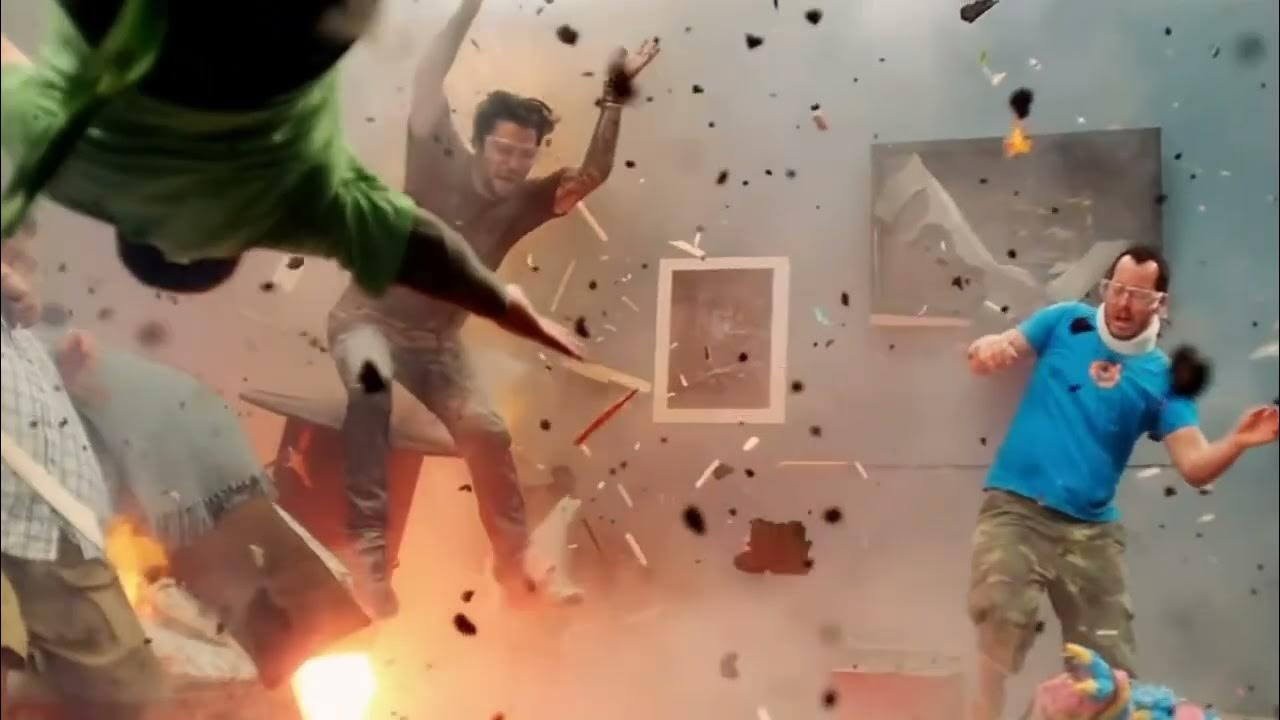

---
## Section 4 — (Optional) LangGraph Preview

> This section is for self-study. We'll cover LangGraph in depth in the next session.

**Why LangGraph?** Our RAG chain is a straight line: retrieve then generate. But production systems need:
- **Quality checks** — is the retrieval good enough?
- **Retries** — re-query if chunks are irrelevant
- **Branching** — different paths for different query types

LangGraph models these as a **state machine** (a graph of nodes and edges), not a linear chain.

In [ ]:
# Install LangGraph (optional)
!pip install -q langgraph==1.1.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 4.3 MB/s eta 0:00:00


In [ ]:
# A minimal LangGraph RAG with quality grading

from typing import TypedDict

from langgraph.graph import END, START, StateGraph


# --- State: what flows through the graph ---
class RAGState(TypedDict):
    question: str
    documents: list[Document]
    answer: str
    retrieval_quality: str


# --- Nodes: each does one job ---
def retrieve(state: RAGState) -> dict:
    """Retrieve relevant documents."""
    docs = retriever.invoke(state["question"])
    return {"documents": docs}


def grade_retrieval(state: RAGState) -> dict:
    """Ask the LLM: are these chunks relevant?"""
    docs_text = format_docs(state["documents"])
    grade_prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a grader. Given a question and "
            "retrieved documents, respond with ONLY "
            "'good' or 'poor'."
            "\n\n"
            "Documents:"
            "\n"
            "{documents}",
        ),
        ("human", "Question: {question}"),
    ])
    chain = grade_prompt | llm | StrOutputParser()
    quality = chain.invoke({
        "documents": docs_text,
        "question": state["question"],
    })
    return {"retrieval_quality": quality.strip().lower()}


def generate(state: RAGState) -> dict:
    """Generate answer from retrieved documents."""
    docs_text = format_docs(state["documents"])
    chain = rag_prompt | llm | StrOutputParser()
    answer = chain.invoke({
        "context": docs_text,
        "question": state["question"],
    })
    return {"answer": answer}


def fallback(state: RAGState) -> dict:
    """Fallback when retrieval quality is poor."""
    return {
        "answer": "I couldn't find relevant information "
        "to answer this question."
    }


# --- Routing ---
def route_by_quality(state: RAGState) -> str:
    if "good" in state.get("retrieval_quality", ""):
        return "generate"
    return "fallback"


# --- Build the graph ---
graph = StateGraph(RAGState)

graph.add_node("retrieve", retrieve)
graph.add_node("grade", grade_retrieval)
graph.add_node("generate", generate)
graph.add_node("fallback", fallback)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "grade")
graph.add_conditional_edges(
    "grade",
    route_by_quality,
    {"generate": "generate", "fallback": "fallback"},
)
graph.add_edge("generate", END)
graph.add_edge("fallback", END)

app = graph.compile()

print("LangGraph RAG pipeline compiled")

LangGraph RAG pipeline compiled


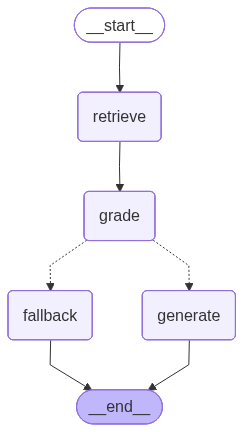

In [ ]:
# Visualize the graph

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# Test: good retrieval

result = app.invoke({
    "question": "What is the meaning of life?",
    "documents": [],
    "answer": "",
    "retrieval_quality": "",
})
print(f"Quality: {result['retrieval_quality']}")
print(f"Answer:  {result['answer']}")

Quality: good
Answer:  Here are a few perspectives from the provided sources:

- Aristotle: The meaning of life is not a single answer but found in the ongoing practice of living virtuously within a community. (source: [1] aristotle.txt)

- Existentialism: Rejected the idea of a given, universal meaning of life. (source: [2] existentialism.txt)

- Stoicism: The meaning of life lies in living according to nature and reason; we cannot control external events, but we can control our responses. (source: [3] stoicism.txt)


In [ ]:
# Test: poor retrieval (out-of-domain question)

result = app.invoke({
    "question": "What is the recipe for chocolate cake?",
    "documents": [],
    "answer": "",
    "retrieval_quality": "",
})
print(f"Quality: {result['retrieval_quality']}")
print(f"Answer:  {result['answer']}")

Quality: poor
Answer:  I couldn't find relevant information to answer this question.


### LangGraph vs LCEL Chains

| Feature | LCEL Chain | LangGraph |
|---------|-----------|-----------|
| Linear flow | Yes | Yes |
| Simple branching (if/else) | Yes (`RunnableBranch`) | Yes |
| Cycles (loop back to earlier step) | **No** (DAG only) | Yes |
| API retry on transient failure | Yes (`.with_retry()`) | Yes |
| Fallback to alternative model | Yes (`.with_fallbacks()`) | Yes |
| Explicit shared state | No (data flows step-to-step) | Yes (`TypedDict`) |
| State persistence / checkpointing | No | Yes |
| Human-in-the-loop | No | Yes (`interrupt()`) |
| Visualization | Yes (`.get_graph()`) | Yes |

**When to use what:**

- **LCEL chains** handle most pipelines well: linear flows, if/else routing, parallel branches, retries on API errors.

- **LangGraph** becomes necessary when you need **shared state**, **cycles**, or **human-in-the-loop**. It can also be more convenient for complex branching.

## Section 5 — RAG in plain Python

**Let's take a step back.**

**Q.** Do we always need LangChain or LangGraph?

**A.** Not really — a simple custom logic can work as well.

In [ ]:
# RAG in plain Python — no chains, no LCEL

query = "What is the meaning of life?"

# Step 1: Retrieve relevant chunks
docs = vectorstore.similarity_search(query, k=3)

# Step 2: Format context as a plain string
context = "\n\n".join(
    f"[{i}] (Source: {doc.metadata['source']})\n"
    f"{doc.page_content}"
    for i, doc in enumerate(docs, 1)
)

# Step 3: Build messages manually
messages = [
    SystemMessage(
        content=(
            "Answer based ONLY on this context. "
            "If the context is insufficient, "
            "say so.\n\n" + context
        ),
    ),
    HumanMessage(content=query),
]

# Step 4: Call the LLM
response = llm.invoke(messages)

print(f"Q: {query}")
print(f"A: {response.content}")


Q: What is the meaning of life?
A: There isn’t a single universal answer. Here are the perspectives from the provided sources:

- Aristotle: The meaning of life is found in the ongoing practice of living virtuously within a community.
- Stoicism: The meaning lies in living according to nature and reason; we can’t control external events, but we can control our responses.
- Existentialism: Rejects the idea of a given, universal meaning of life (meaning isn’t pre-set).


---
## Summary

**What you built today:**
1. LangChain chains with prompt templates and LCEL
2. A complete RAG pipeline: chunk, embed, store, retrieve, generate
3. Identified where basic RAG fails

**What's next (homework):**
- Revise what we've done
- Tune the pipeline for better accuracy (chunking, prompts, retrieval params)
- Implement advanced RAG techniques: query expansion, re-ranking, hybrid search

***

**Key takeaway:** RAG is not magic — it's an engineering system. Each component can be tuned, and the right technique depends on your specific failure mode. For complex tasks (such as finding the meaning of life) advanced RAG methods might be required.

***

**It was hidden under the rag, but:** beware if your quest for the meaning of life leads you off the beaten path — the LangChain ecosystem can be hard to work when you need custom logic or bleeding-edge or niche models.

**You don't always need a fancy LLM framework:** LangChain and LangGraph are NOT strictly required to find the meaning of life.